In [1]:
import yfinance as yf

In [2]:
sp500 = yf.Ticker("^GSPC")

In [3]:
sp500 = sp500.history(period='max')

In [4]:
sp500.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-02-24 00:00:00-05:00,6837.370117,6899.169922,6815.430176,6890.069824,5266090000,0.0,0.0
2026-02-25 00:00:00-05:00,6915.149902,6952.509766,6915.149902,6946.129883,5328060000,0.0,0.0
2026-02-26 00:00:00-05:00,6944.740234,6947.250000,6859.729980,6908.859863,5889550000,0.0,0.0
2026-02-27 00:00:00-05:00,6856.540039,6882.959961,6831.740234,6878.879883,6665660000,0.0,0.0
2026-03-02 00:00:00-05:00,6824.359863,6889.029785,6796.850098,6875.709961,1912932000,0.0,0.0


In [5]:
sp500.index

DatetimeIndex(['1927-12-30 00:00:00-05:00', '1928-01-03 00:00:00-05:00',
               '1928-01-04 00:00:00-05:00', '1928-01-05 00:00:00-05:00',
               '1928-01-06 00:00:00-05:00', '1928-01-09 00:00:00-05:00',
               '1928-01-10 00:00:00-05:00', '1928-01-11 00:00:00-05:00',
               '1928-01-12 00:00:00-05:00', '1928-01-13 00:00:00-05:00',
               ...
               '2026-02-17 00:00:00-05:00', '2026-02-18 00:00:00-05:00',
               '2026-02-19 00:00:00-05:00', '2026-02-20 00:00:00-05:00',
               '2026-02-23 00:00:00-05:00', '2026-02-24 00:00:00-05:00',
               '2026-02-25 00:00:00-05:00', '2026-02-26 00:00:00-05:00',
               '2026-02-27 00:00:00-05:00', '2026-03-02 00:00:00-05:00'],
              dtype='datetime64[ns, America/New_York]', name='Date', length=24657, freq=None)

<Axes: xlabel='Date'>

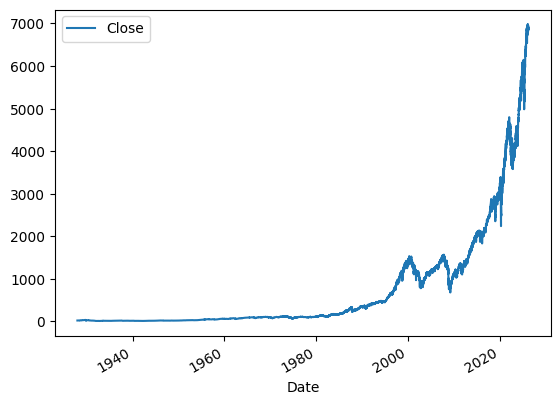

In [6]:
sp500.plot.line(y='Close')

In [7]:
#del sp500['Dividends']
del sp500['Stock Splits']

In [8]:
sp500['tomorrow'] = sp500['Close'].shift(-1)

In [9]:
sp500

,Open,High,Low,Close,Volume,Dividends,tomorrow
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,17.760000
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,17.719999
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,17.549999
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,17.660000
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,17.500000
...,...,...,...,...,...,...,...
2026-02-24 00:00:00-05:00,6837.370117,6899.169922,6815.430176,6890.069824,5266090000,0.0,6946.129883
2026-02-25 00:00:00-05:00,6915.149902,6952.509766,6915.149902,6946.129883,5328060000,0.0,6908.859863
2026-02-26 00:00:00-05:00,6944.740234,6947.250000,6859.729980,6908.859863,5889550000,0.0,6878.879883


In [10]:
sp500['target'] = (sp500['tomorrow'] > sp500['Close']).astype(int)

In [11]:
sp500

,Open,High,Low,Close,Volume,Dividends,tomorrow,target
Date,,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,17.760000,1
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,17.719999,0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,17.549999,0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,17.660000,1
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,17.500000,0
...,...,...,...,...,...,...,...,...
2026-02-24 00:00:00-05:00,6837.370117,6899.169922,6815.430176,6890.069824,5266090000,0.0,6946.129883,1
2026-02-25 00:00:00-05:00,6915.149902,6952.509766,6915.149902,6946.129883,5328060000,0.0,6908.859863,0
2026-02-26 00:00:00-05:00,6944.740234,6947.250000,6859.729980,6908.859863,5889550000,0.0,6878.879883,0


In [12]:
sp500 = sp500.loc['1990-01-01':].copy()

<Axes: xlabel='Date'>

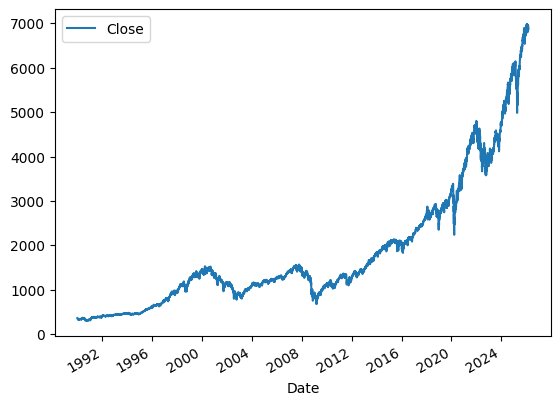

In [13]:
sp500.plot.line(y='Close')

In [14]:
from sklearn.ensemble import RandomForestClassifier

In [15]:
model = RandomForestClassifier(n_estimators=100, min_samples_split=100, random_state=1)

In [16]:
train = sp500.iloc[:-100]
test = sp500.iloc[-100:]

In [17]:
X= ['Close','Volume', 'Open', 'High','Low']
y=['target']

In [18]:
model.fit(train[X],train[y])

C:\Users\erick\anaconda3\envs\ca1\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,100
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
from sklearn.metrics import precision_score

In [20]:
pred = model.predict(test[X])

In [21]:
pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0])

In [22]:
import pandas as pd
pred = pd.Series(pred, index=test.index)

In [23]:
pred

Date
2025-10-07 00:00:00-04:00    1
2025-10-08 00:00:00-04:00    1
2025-10-09 00:00:00-04:00    1
2025-10-10 00:00:00-04:00    1
2025-10-13 00:00:00-04:00    1
                            ..
2026-02-24 00:00:00-05:00    1
2026-02-25 00:00:00-05:00    1
2026-02-26 00:00:00-05:00    1
2026-02-27 00:00:00-05:00    1
2026-03-02 00:00:00-05:00    0
Length: 100, dtype: int64

In [24]:
precision_score(test[y],pred)

0.5612244897959183

In [25]:
combined = pd.concat([test['target'],pred], axis=1)

<Axes: xlabel='Date'>

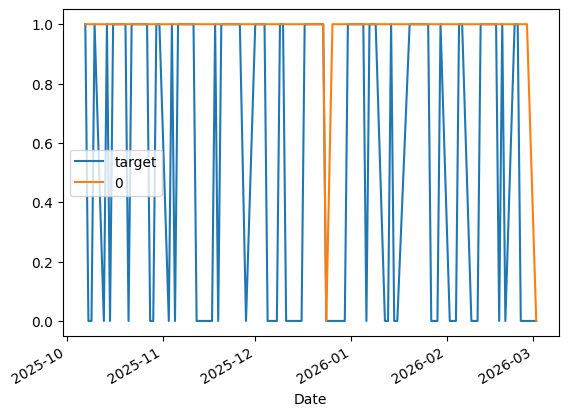

In [26]:
combined.plot()

In [27]:
def predict(train, test, X, model):
    model.fit(train[X],train['target'])
    pred = model.predict(test[X])
    pred = pd.Series(pred, index=test.index, name='Prediction')
    combined = pd.concat([test['target'], pred], axis=1)
    return combined

In [28]:
def backtest( data, model, X, start =2500, step=250):
    all_predictions = []

    for i in range(start, data.shape[0], step):
        train= data.iloc[0:i]
        test= data.iloc[i:(i+step)]
        predictions= predict(train,test,X,model)
        all_predictions.append(predictions)
    return pd.concat(all_predictions)

In [29]:
predictions = backtest(sp500, model, X)

In [30]:
predictions['Prediction'].value_counts()

Prediction
0    3937
1    2670
Name: count, dtype: int64

In [31]:
precision_score(predictions['target'], predictions['Prediction'])

0.5307116104868914

In [32]:
predictions['target'].value_counts() / predictions.shape[0]

target
1    0.537309
0    0.462691
Name: count, dtype: float64

In [33]:
horizons=[2,5,60,250,1000]
new_predictors = []

for horizon in horizons:
    rolling_averanges= sp500.rolling(horizon).mean()
    ratio_column = f"Close_Ratio_{horizon}"
    sp500[ratio_column] = sp500['Close'] / rolling_averanges['Close']

    trend_column = f'Trend_{horizon}'
    sp500[trend_column] = sp500.shift(1).rolling(horizon).sum()['target']

    new_predictors += [ratio_column, trend_column]

In [34]:
sp500

,Open,High,Low,Close,Volume,Dividends,tomorrow,target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000,0.0,358.760010,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000,0.0,355.670013,0,0.998706,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000,0.0,352.200012,0,0.995675,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-05 00:00:00-05:00,355.670013,355.670013,351.350006,352.200012,158530000,0.0,353.790009,1,0.995098,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-08 00:00:00-05:00,352.200012,354.239990,350.540009,353.790009,140110000,0.0,349.619995,0,1.002252,1.0,0.993731,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-24 00:00:00-05:00,6837.370117,6899.169922,6815.430176,6890.069824,5266090000,0.0,6946.129883,1,1.003811,1.0,1.002031,3.0,1.000351,33.0,1.085738,144.0,1.352356,536.0
2026-02-25 00:00:00-05:00,6915.149902,6952.509766,6915.149902,6946.129883,5328060000,0.0,6908.859863,0,1.004052,2.0,1.008283,3.0,1.008164,33.0,1.093890,144.0,1.362654,537.0
2026-02-26 00:00:00-05:00,6944.740234,6947.250000,6859.729980,6908.859863,5889550000,0.0,6878.879883,0,0.997310,1.0,1.001507,3.0,1.002610,32.0,1.087303,144.0,1.354672,536.0


In [36]:
sp500 = sp500.dropna()

In [37]:
model = RandomForestClassifier(n_estimators=200, min_samples_split=50, random_state=1)

In [43]:
def predict(train, test, X, model):
    model.fit(train[X],train[y])
    pred = model.predict_proba(test[X])[:,1]
    pred[pred >=.6] =1
    pred[pred <=.6] =0
    pred = pd.Series(pred, index=test.index, name='Predictions')
    combined = pd.concat([test[y], pred], axis=1)
    return combined

In [44]:
predictions = backtest(sp500, model, new_predictors)

C:\Users\erick\anaconda3\envs\ca1\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\erick\anaconda3\envs\ca1\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\erick\anaconda3\envs\ca1\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\erick\anaconda3\envs\ca1\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change

In [45]:
predictions['Predictions'].value_counts()

Predictions
0.0    4733
1.0     873
Name: count, dtype: int64

In [46]:
precision_score(predictions[y], predictions["Predictions"])

0.572737686139748

In [47]:
predictions["target"].value_counts() / predictions.shape[0]

target
1    0.546736
0    0.453264
Name: count, dtype: float64

In [48]:

predictions

,target,Predictions
Date,,
2003-11-14 00:00:00-05:00,0,0.0
2003-11-17 00:00:00-05:00,0,1.0
2003-11-18 00:00:00-05:00,1,1.0
2003-11-19 00:00:00-05:00,0,0.0
2003-11-20 00:00:00-05:00,1,1.0
...,...,...
2026-02-23 00:00:00-05:00,1,0.0
2026-02-24 00:00:00-05:00,1,0.0
2026-02-25 00:00:00-05:00,0,0.0
